In [2]:
import torch
print(torch.__version__)


2.9.1+cpu


In [3]:
import sys, os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, PROJECT_ROOT)

from utils.hospital_env import HospitalEnv


Using device: cpu


In [4]:
data = pd.read_csv("../data/synthetic_hospital_data.csv")
env = HospitalEnv(data)

STATE_DIM = 5
ACTION_DIM = 2


In [5]:
def normalize_state(state):
    arrival, slot, priority, no_show, icu_ratio = state
    return np.array([
        arrival / 480.0,
        slot / 480.0,
        priority / 2.0,
        no_show,
        icu_ratio
    ], dtype=np.float32)


In [6]:
class DQN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(STATE_DIM, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, ACTION_DIM)
        )

    def forward(self, x):
        return self.net(x)


In [7]:
class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)

    def push(self, s, a, r, ns, d):
        self.buffer.append((s, a, r, ns, d))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        s, a, r, ns, d = zip(*batch)

        return (
            np.array(s),
            np.array(a),
            np.array(r),
            np.array(ns),
            np.array(d)
        )

    def __len__(self):
        return len(self.buffer)


In [8]:
episodes = 200
batch_size = 64
gamma = 0.99
epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.995
lr = 1e-3
target_update = 5


In [9]:
policy_net = DQN().to(device)
target_net = DQN().to(device)

target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=lr)
memory = ReplayBuffer()


Episode 1: Total Reward = -2096
Episode 2: Total Reward = -2123
Episode 3: Total Reward = -1555
Episode 4: Total Reward = -1928
Episode 5: Total Reward = -1474
Episode 6: Total Reward = -1870
Episode 7: Total Reward = -1850
Episode 8: Total Reward = -1859
Episode 9: Total Reward = -1615
Episode 10: Total Reward = -1818
Episode 11: Total Reward = -1576
Episode 12: Total Reward = -1781
Episode 13: Total Reward = -2057
Episode 14: Total Reward = -1538
Episode 15: Total Reward = -1542
Episode 16: Total Reward = -1234
Episode 17: Total Reward = -2051
Episode 18: Total Reward = -1817
Episode 19: Total Reward = -2143
Episode 20: Total Reward = -1741
Episode 21: Total Reward = -2193
Episode 22: Total Reward = -1287
Episode 23: Total Reward = -1899
Episode 24: Total Reward = -1576
Episode 25: Total Reward = -1677
Episode 26: Total Reward = -1421
Episode 27: Total Reward = -1987
Episode 28: Total Reward = -1152
Episode 29: Total Reward = -1715
Episode 30: Total Reward = -1648
Episode 31: Total R

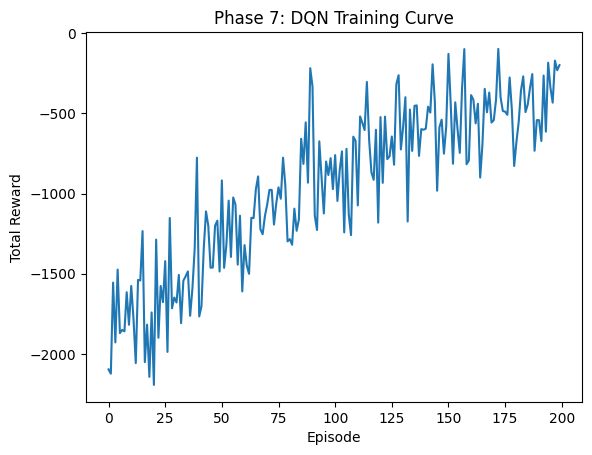

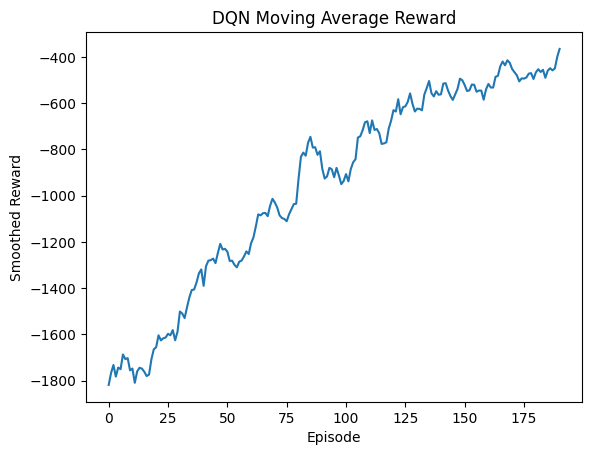

In [10]:
episode_rewards = []
losses = []
env = HospitalEnv(data)
for ep in range(episodes):              
    state = normalize_state(env.reset())
    done = False
    total_reward = 0

    while not done:
        # ε-greedy action
        if random.random() < epsilon:
            action = random.randint(0, 1)
        else:
            with torch.no_grad():
                state_tensor = torch.from_numpy(state).float().unsqueeze(0).to(device)
                q_vals = policy_net(state_tensor)
                action = torch.argmax(q_vals, dim=1).item()


        next_state, reward, done = env.step(action)
        next_state_n = (
            normalize_state(next_state)
            if not done else np.zeros(STATE_DIM, dtype=np.float32)
        )

        memory.push(state, action, reward, next_state_n, done)
        state = next_state_n
        total_reward += reward

        # Train step
        if len(memory) >= 1000:
            s, a, r, ns, d = memory.sample(batch_size)

            s  = torch.from_numpy(s).float().to(device)
            ns = torch.from_numpy(ns).float().to(device)
            a  = torch.tensor(a, dtype=torch.long).to(device)    
            r  = torch.tensor(r, dtype=torch.float32).to(device)
            d  = torch.tensor(d, dtype=torch.float32).to(device)

            q_pred = policy_net(s).gather(1, a.unsqueeze(1)).squeeze()

            with torch.no_grad():
                q_next = target_net(ns).max(1)[0]
                q_target = r + gamma * q_next * (1 - d)

            loss = nn.MSELoss()(q_pred, q_target)
            losses.append(loss.item())

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(policy_net.parameters(), 1.0)
            optimizer.step()

    # Target network update
    if (ep + 1) % target_update == 0:
        target_net.load_state_dict(policy_net.state_dict())

    # Epsilon decay
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    episode_rewards.append(total_reward)
    print(f"Episode {ep+1}: Total Reward = {total_reward}")

print("\nTraining completed.")


plt.figure()
plt.plot(episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Phase 7: DQN Training Curve")
plt.show()
window = 10
moving_avg = np.convolve(episode_rewards, np.ones(window)/window, mode='valid')

plt.figure()
plt.plot(moving_avg)
plt.title("DQN Moving Average Reward")
plt.xlabel("Episode")
plt.ylabel("Smoothed Reward")
plt.show()

In [11]:
# ============================================
# SAVE TRAINING ARTIFACTS (ADD THIS NEW CELL)
# ============================================

import os
import pandas as pd

# Create folders if they don't exist
os.makedirs("results", exist_ok=True)
os.makedirs("models", exist_ok=True)

# -----------------------------
# Save Reward Curve
# -----------------------------
rewards_df = pd.DataFrame({
    "episode": list(range(1, len(episode_rewards) + 1)),
    "reward": episode_rewards
})

rewards_df.to_csv("results/dqn_rewards.csv", index=False)

# -----------------------------
# Save Loss Curve
# -----------------------------
loss_df = pd.DataFrame({
    "loss": losses
})

loss_df.to_csv("results/dqn_losses.csv", index=False)

# -----------------------------
# Save Model
# -----------------------------
torch.save(policy_net.state_dict(), "models/dqn_model.pt")

print("✅ DQN training artifacts saved successfully.")


✅ DQN training artifacts saved successfully.
